In [1]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import os
import glob
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn
from torch_geometric.nn import EdgeConv 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import kneighbors_graph

Welcome to JupyROOT 6.26/16


In [2]:
#Just a testbench for our models, to display training curves and perform inference etc. 
graph_file_directory = '/sdf/data/neutrino/summer25/ktwall/processed/' #directory containing graph datasets.
graph_file_paths = glob.glob(os.path.join(graph_file_directory, "*.pt")) 

In [3]:
#Testing set that contains 5 files worth of graphs
testing_file_paths = graph_file_paths[95:100]
testing_datasets_list = []
for testing_path in testing_file_paths:
    testing_datasets_list.append(torch.load(testing_path))

testing_dataset = ConcatDataset(testing_datasets_list)
print('loaded testing dataset')

train_file_paths = graph_file_paths[0:90]
training_datasets_list = []
for i, train_path in enumerate(train_file_paths):
    training_datasets_list.append(torch.load(train_path))
    if (i % 10 == 0):
        print(f'training loaded {i}')
    
training_dataset = ConcatDataset(training_datasets_list)
print('loaded training dataset')

#Validation set that contains 5 files worth of graphs
validation_file_paths = graph_file_paths[90:95]
validation_datasets_list = []
for validation_path in validation_file_paths:
    validation_datasets_list.append(torch.load(validation_path))

validation_dataset = ConcatDataset(validation_datasets_list)
print('loaded validation dataset')

/lscratch/ktwall/tmp/ipykernel_4141561/3759286059.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  testing_datasets_list.append(torch.load(testing_path))


loaded testing dataset


/lscratch/ktwall/tmp/ipykernel_4141561/3759286059.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  training_datasets_list.append(torch.load(train_path))


training loaded 0
training loaded 10
training loaded 20
training loaded 30
training loaded 40
training loaded 50
training loaded 60
training loaded 70
training loaded 80
loaded training dataset


/lscratch/ktwall/tmp/ipykernel_4141561/3759286059.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  validation_datasets_list.append(torch.load(validation_path))


loaded validation dataset


In [4]:
graph_file_paths[95:100]

['/sdf/data/neutrino/summer25/ktwall/processed/file_2504_graphs.pt',
 '/sdf/data/neutrino/summer25/ktwall/processed/file_2468_graphs.pt',
 '/sdf/data/neutrino/summer25/ktwall/processed/file_2535_graphs.pt',
 '/sdf/data/neutrino/summer25/ktwall/processed/file_2553_graphs.pt',
 '/sdf/data/neutrino/summer25/ktwall/processed/file_2499_graphs.pt']

In [5]:
batch = 1000
#train
training_data_loader = DataLoader(training_dataset, batch_size = batch, drop_last = True, shuffle=True, num_workers=2)
print(f'Training on {len(training_data_loader)*training_data_loader.batch_size} total graphs')

#validate
validation_data_loader = DataLoader(validation_dataset, batch_size = batch, drop_last = True, shuffle=True)
print(f'Validating on {len(validation_data_loader)*validation_data_loader.batch_size} total graphs')

#test
testing_data_loader = DataLoader(testing_dataset, batch_size = 1000, drop_last = True, shuffle=True)
print(f'Training on {len(testing_data_loader)*testing_data_loader.batch_size} total graphs')

Training on 228000 total graphs
Validating on 12000 total graphs
Training on 12000 total graphs


Text(0.5, 1.0, 'Truth Label Fraction')

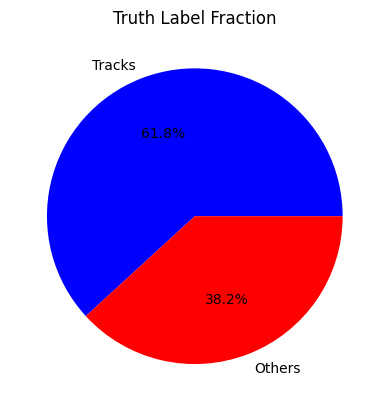

In [6]:
#Lets compile some node level statistics on our training data. 
tracks = 0
others = 0
total = 0
for data in training_dataset:
    labels = data.y
    total += len(data.y)
    uniques, counts = np.unique(labels, return_counts=True)
    for i, label in enumerate(uniques):
        if label == 0:
            tracks += counts[i]
        if label == 1:
            others += counts[i]

sizes = np.array([tracks, others])
categories = ['Tracks', 'Others']
colors = ['blue', 'red']

plt.pie(sizes, labels=categories, colors = colors, autopct='%.1f%%')
plt.title("Truth Label Fraction")

In [7]:
#Now, the architecture. GCN Based
class Arthur1(torch.nn.Module):
    def __init__(self, in_channels, hc1, hc2, hc3, fc1, fc2, fc3, out_channels): # we define all of the convolutions and layers here
        super(Arthur1, self).__init__()
        self.convolution1 = gcn(in_channels, hc1) 
        self.bn1 = torch.nn.BatchNorm1d(hc1)
        self.convolution2 = gcn(hc1, hc2) 
        self.bn2 = torch.nn.BatchNorm1d(hc2)
        self.convolution3 = gcn(hc2, hc3)
        self.bn3 = torch.nn.BatchNorm1d(hc3)
        self.linear1 = torch.nn.Linear(hc3, fc1) 
        self.linear2 = torch.nn.Linear(fc1, fc2)
        self.linear3 = torch.nn.Linear(fc2, fc3)
        self.linear4 = torch.nn.Linear(fc3, out_channels)

        self.parameter_init()

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.convolution1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.convolution2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.convolution3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.linear2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.linear3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.linear4(x)
        return(x) #going to change the model to apply the log softmax at inference. 

    def parameter_init(self):
        for module in self.modules():
            if isinstance(module, (torch.nn.Linear)):
                torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu') #set weights to random from uniform weighted on Relu
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias) #set biases to zero (if there are any)


class BerthaStatic(torch.nn.Module):
    def __init__(self, in_channels, hc1, hc2, hc3, fc1, fc2, fc3, out_channels): # we define all of the convolutions and layers here
        super(BerthaStatic, self).__init__()
        
        self.mlp1 = torch.nn.Sequential(
            torch.nn.Linear(in_channels * 2, hc1),
            torch.nn.ReLU(),
            torch.nn.Linear(hc1, hc1)
        )
        self.mlp2 = torch.nn.Sequential(
            torch.nn.Linear(hc1 * 2, hc2),
            torch.nn.ReLU(),
            torch.nn.Linear(hc2, hc2)
        ) 
        self.mlp3 = torch.nn.Sequential(
            torch.nn.Linear(hc2 * 2 , hc3),
            torch.nn.ReLU(),
            torch.nn.Linear(hc3, hc3)
        )  
        
        self.edgeconv1 = EdgeConv(self.mlp1, aggr='max')
        self.bn1 = torch.nn.BatchNorm1d(hc1)
        
        self.edgeconv2 = EdgeConv(self.mlp2, aggr='max') 
        self.bn2 = torch.nn.BatchNorm1d(hc2)
        
        self.edgeconv3 = EdgeConv(self.mlp3, aggr='max')
        self.bn3 = torch.nn.BatchNorm1d(hc3)
        
        self.linear1 = torch.nn.Linear(hc3, fc1) 
        self.linear2 = torch.nn.Linear(fc1, fc2)
        self.linear3 = torch.nn.Linear(fc2, fc3)
        self.linear4 = torch.nn.Linear(fc3, out_channels)

        self.parameter_init()

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.edgeconv1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.edgeconv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.edgeconv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear4(x)
        return(x) #going to change the model to apply the log softmax at inference. 

    def parameter_init(self):
        for module in self.modules():
            if isinstance(module, (torch.nn.Linear)):
                torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu') #set weights to random from uniform weighted on Relu
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias) #set biases to zero (if there are any)

In [8]:
def run_inference(model, test_loader):
    model.eval()
    with torch.no_grad():
        i = 0
        total_correct = 0
        for data in test_loader:
            out = model(data.x, data.edge_index)
            inference = F.log_softmax(out, dim=1)
            n_correct = torch.sum(inference.argmax(dim=1) == (data.y))
            i += len(data.y)
            total_correct += n_correct
    return(total_correct / i)

In [9]:
Bertha_state_dict = torch.load('/sdf/data/neutrino/summer25/ktwall/logs_Bertha/delaunay-BerthaStatic-GPU-train90-batch1000-p02.pth', weights_only = True, map_location=torch.device('cpu'))
BerthaStatic_preload = BerthaStatic(in_channels = 3, hc1 = 20, hc2 = 40, hc3 = 50, fc1 = 25, fc2 = 12, fc3 = 6, out_channels = 2)
BerthaStatic_preload.load_state_dict(Bertha_state_dict)
BerthaStatic_preload.eval()

BerthaStatic(
  (mlp1): Sequential(
    (0): Linear(in_features=6, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
  )
  (mlp2): Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
  )
  (mlp3): Sequential(
    (0): Linear(in_features=80, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
  )
  (edgeconv1): EdgeConv(nn=Sequential(
    (0): Linear(in_features=6, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
  ))
  (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (edgeconv2): EdgeConv(nn=Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
  ))
  (bn2): BatchNorm1d(40, eps=1e-05, momentum=0.1, aff

In [10]:
run_inference(BerthaStatic_preload, testing_data_loader)

tensor(0.9094)

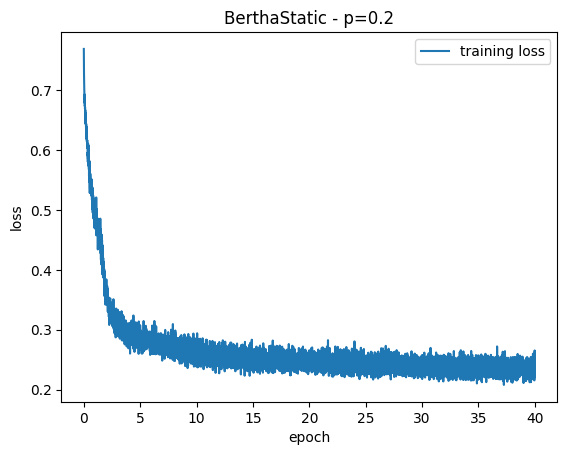

In [11]:
import pandas as pd
df1 = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_Bertha/delaunay-BerthaStatic-GPU-batch1000-p02train.csv')
df2 = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_Bertha/delaunay-BerthaStatic-GPU-batch1000-p02val.csv')
rolling_1 = df1.rolling(1).mean()
plt.plot(rolling_1['epoch'], rolling_1['loss'], label = 'training loss')
plt.xlabel('epoch')
#plt.yscale('log')
plt.ylabel('loss')
plt.title('BerthaStatic - p=0.2')
plt.legend()

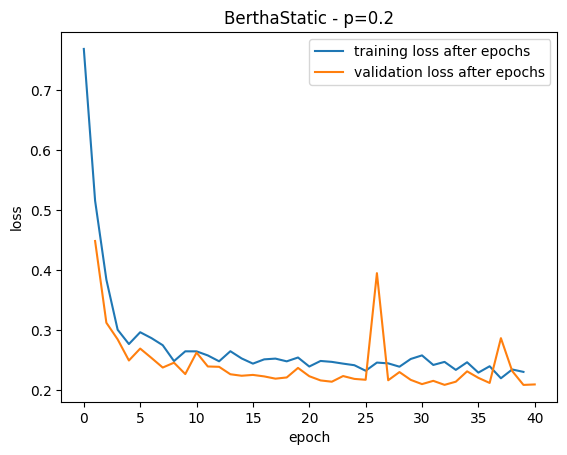

In [12]:
training_frame = df1.to_numpy()
epoch_wise_training = training_frame[training_frame[:,0] % 228 == 0]
validation_frame = df2.to_numpy()
plt.plot(epoch_wise_training[:,1], epoch_wise_training[:,2], label = 'training loss after epochs')
plt.plot(validation_frame[:,1], validation_frame[:,2], label = 'validation loss after epochs')
#plt.ylim(0.50,0.66)
plt.ylabel('loss')
plt.title('')
plt.xlabel('epoch')
plt.title('BerthaStatic - p=0.2')
plt.legend()

In [13]:
#lets investigate a little bit. How is our labeling actually looking?

inference_list = []
graph_list = []
node_to_graph = []

for data in testing_data_loader:
    graph_list.append(data)
    node_to_graph.append(data.batch)
    out = BerthaStatic_preload(data.x, data.edge_index)
    inference = F.log_softmax(out, dim=1)
    inference_list.append(inference.argmax(dim=1))

#map back to graphs:
full_graphs_list = []
graph_finder = []
grouped_nodes_list = []
for i, nodes in enumerate(graph_list):
    labels = (inference_list[i]).numpy()
    node_array = (nodes.x).numpy()
    truth_labels = (nodes.y).numpy()
    batch_array = (nodes.batch).numpy()
    occupancy = (nodes.occupancy).numpy()
    file_no_arr = (nodes.file_number).numpy()
    graph_no_arr = (nodes.graph_number).numpy()
    grouped_nodes = np.column_stack((node_array,batch_array, truth_labels, labels)) #node info, graph #, truth label, inferences label
    grouped_nodes_list.append(grouped_nodes)
    for graph_n in np.unique(grouped_nodes[:,-3]):
        file = file_no_arr[int(graph_n)]
        graph_number = graph_no_arr[int(graph_n)]
        graph_n_subarray = grouped_nodes[grouped_nodes[:,-3] == graph_n]
        full_graphs_list.append(graph_n_subarray)
        graph_finder.append((file,graph_number))

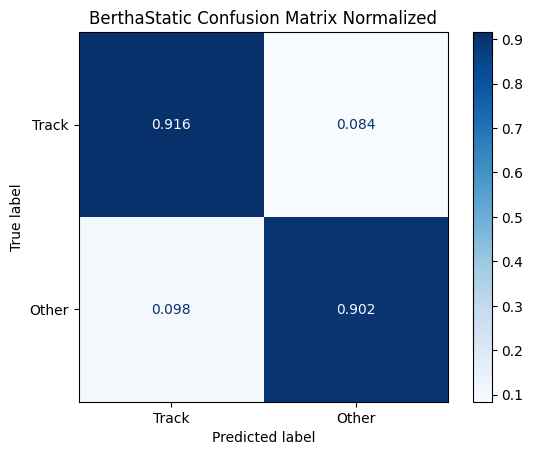

In [14]:
full_stack = np.vstack(grouped_nodes_list)
np.shape(full_stack)
y_true = full_stack[:,-2]
y_pred = full_stack[:,-1]
label_names = ['Track', 'Other']
cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format=".3f")
plt.title('BerthaStatic Confusion Matrix Normalized')
plt.show()

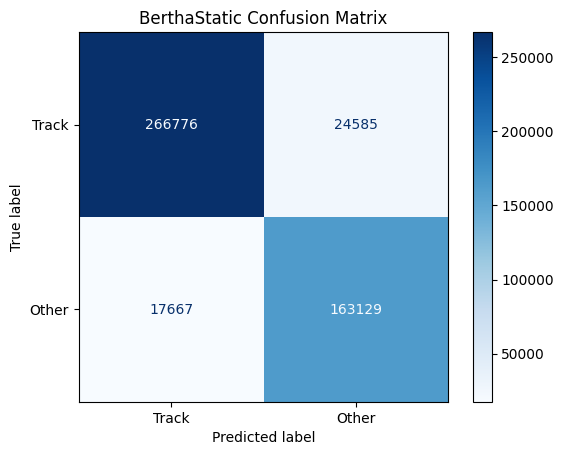

In [15]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('BerthaStatic Confusion Matrix')
plt.show()

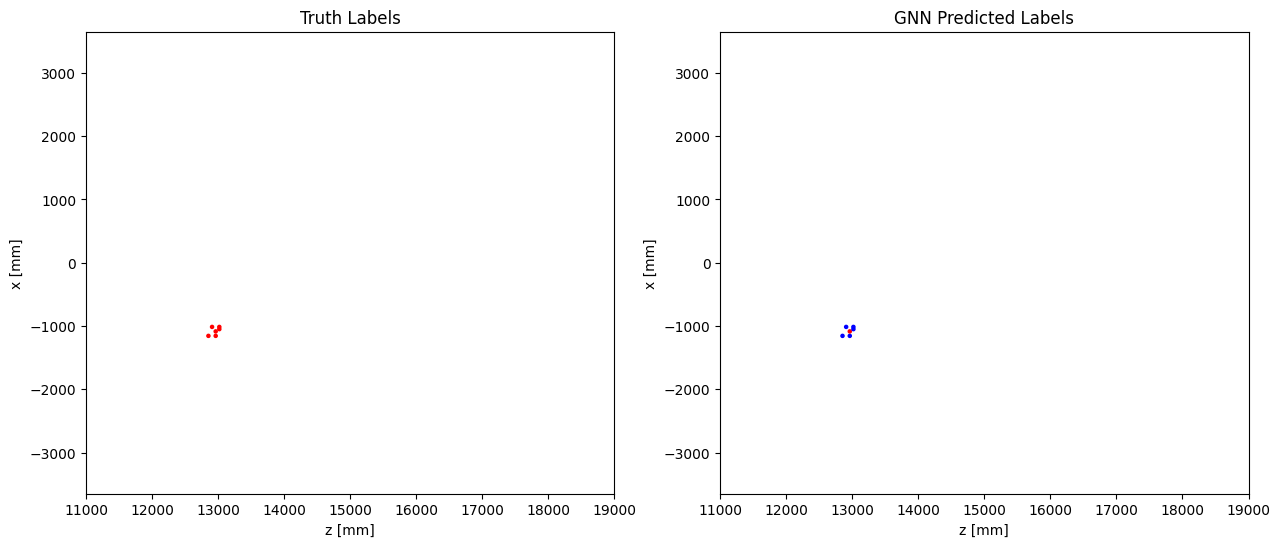

In [55]:
#lets see how it is doing!
#selected cluster, can now take a look at the truth labels.
cluster_n = 502 #row_indices[0] #6421
nodes = full_graphs_list[cluster_n]
zs = nodes[:,0]
xs = nodes[:,1]
true_labels = nodes[:,-2]
inference_labels = nodes[:,-1]

truth_colors = []
for true_label in true_labels:
    if true_label == 0:
        truth_colors.append('blue')
    else:
        truth_colors.append('red')
        
inference_colors = [] 
for inf_label in inference_labels:
    if inf_label == 0:
        inference_colors.append('blue')
    else:
        inference_colors.append('red')

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15,6))

sc1 = ax1.scatter(zs, xs, s = 5, c = truth_colors)
ax1.set_title(f'Truth Labels')
ax1.set_ylim((-3650,3650))
ax1.set_xlim((11000,19000))
ax1.set_xlabel("z [mm]")
ax1.set_ylabel("x [mm]")

sc2 = ax2.scatter(zs, xs, s = 5, c = inference_colors)
ax2.set_title(f'GNN Predicted Labels')
ax2.set_ylim((-3650,3650))
ax2.set_xlim((11000,19000))
ax2.set_xlabel("z [mm]")
ax2.set_ylabel("x [mm]")

plt.savefig('comparison_labels')

In [17]:
cluster_ns = (np.array(graph_finder))[:,1]
print(np.where(cluster_ns == 85))
graph_finder[5711]

(array([  990,  3174,  4572,  7790, 10614]),)


(np.int64(2499), np.int64(1338))